In [7]:
import random
import time
import math
from multiprocessing import Pool

# =========================
# FUNGSI PARALLEL
# =========================
def monte_carlo_part(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            inside_circle += 1
    return inside_circle


def calculate_pi_parallel(total_samples, num_processes):
    samples = [total_samples // num_processes] * num_processes
    samples[0] += total_samples % num_processes

    with Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_part, samples)

    total_inside = sum(results)
    return 4 * total_inside / total_samples


# =========================
# SERIAL (UNTUK SPEEDUP)
# =========================
def calculate_pi_serial(num_samples):
    inside_circle = 0
    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x*x + y*y <= 1:
            inside_circle += 1
    return 4 * inside_circle / num_samples


# =========================
# EKSPERIMEN
# =========================
if __name__ == "__main__":

    total_samples = 10_000_000
    thread_counts = [1, 2, 4, 8, 16, 32]

    # ===== SERIAL =====
    start = time.perf_counter()
    pi_serial = calculate_pi_serial(total_samples)
    end = time.perf_counter()

    serial_time = end - start

    print("\n===== SERIAL =====")
    print(f"Waktu: {serial_time:.4f}")
    print(f"Pi: {pi_serial}")

    # ===== PARALLEL =====
    times = []
    pis = []

    print("\n===== PARALLEL =====")
    for t in thread_counts:
        start = time.perf_counter()
        pi_est = calculate_pi_parallel(total_samples, t)
        end = time.perf_counter()

        exec_time = end - start

        times.append(exec_time)
        pis.append(pi_est)

        print(f"Thread: {t} | Waktu: {exec_time:.4f} | Pi: {pi_est}")

    # ===== SPEEDUP & EFFICIENCY =====
    speedups = [serial_time / t for t in times]
    efficiency = [s / p for s, p in zip(speedups, thread_counts)]

    print("\n===== ANALISIS =====")
    for i in range(len(thread_counts)):
        print(f"Thread {thread_counts[i]}")
        print(f"  Speedup   : {speedups[i]:.2f}")
        print(f"  Efficiency: {efficiency[i]:.2f}")


===== SERIAL =====
Waktu: 9.3100
Pi: 3.141716

===== PARALLEL =====
Thread: 1 | Waktu: 9.3440 | Pi: 3.1424568
Thread: 2 | Waktu: 6.2022 | Pi: 3.1411948
Thread: 4 | Waktu: 6.3164 | Pi: 3.1421088
Thread: 8 | Waktu: 6.6225 | Pi: 3.141134
Thread: 16 | Waktu: 5.5220 | Pi: 3.1405684
Thread: 32 | Waktu: 7.8672 | Pi: 3.1421516

===== ANALISIS =====
Thread 1
  Speedup   : 1.00
  Efficiency: 1.00
Thread 2
  Speedup   : 1.50
  Efficiency: 0.75
Thread 4
  Speedup   : 1.47
  Efficiency: 0.37
Thread 8
  Speedup   : 1.41
  Efficiency: 0.18
Thread 16
  Speedup   : 1.69
  Efficiency: 0.11
Thread 32
  Speedup   : 1.18
  Efficiency: 0.04


## Speedup vs Jumlah Thread

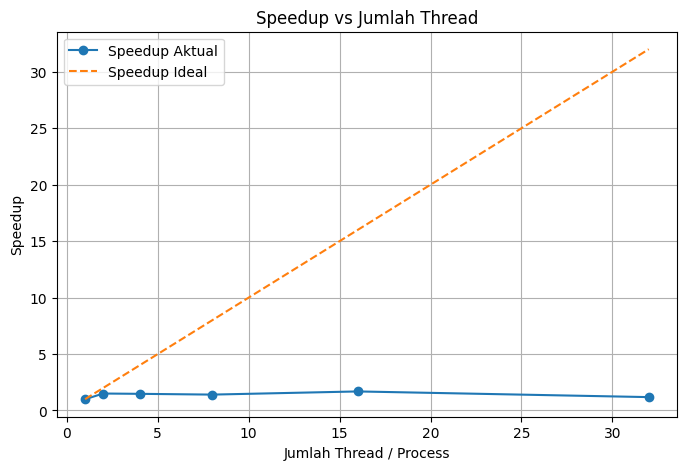

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

# Speedup aktual
plt.plot(thread_counts, speedups, marker='o', label='Speedup Aktual')

# Speedup ideal (linear)
plt.plot(thread_counts, thread_counts, linestyle='--', label='Speedup Ideal')

plt.xlabel('Jumlah Thread / Process')
plt.ylabel('Speedup')
plt.title('Speedup vs Jumlah Thread')

plt.legend()
plt.grid()

plt.savefig('speedup_vs_thread.png')
plt.show()

## Efficiency vs Jumlah Thread

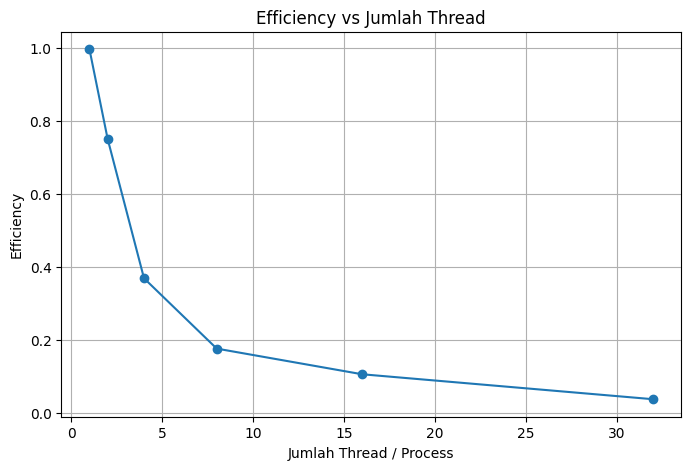

In [9]:
plt.figure(figsize=(8,5))

plt.plot(thread_counts, efficiency, marker='o')

plt.xlabel('Jumlah Thread / Process')
plt.ylabel('Efficiency')
plt.title('Efficiency vs Jumlah Thread')

plt.grid()

plt.savefig('efficiency_vs_thread.png')
plt.show()

## Waktu Eksekusi vs Jumlah Thread

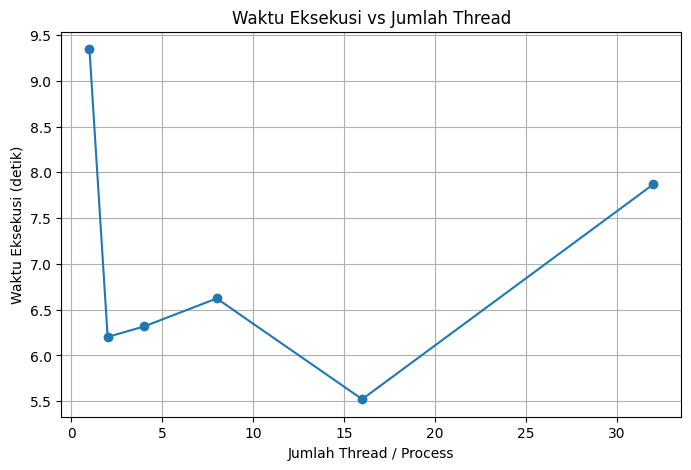

In [10]:
plt.figure(figsize=(8,5))

plt.plot(thread_counts, times, marker='o')

plt.xlabel('Jumlah Thread / Process')
plt.ylabel('Waktu Eksekusi (detik)')
plt.title('Waktu Eksekusi vs Jumlah Thread')

plt.grid()

plt.savefig('time_vs_thread.png')
plt.show()